In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict

# Simple Parallel Workflow (W/O LLM)

In [6]:
class BatsmanState(TypedDict):
    runs: float
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    boundary_percent: float
    summary: str
    

**Reason for adding dict in output of node and returning dict**  
When working with parallel workflows, LangGraph seems to think that you have changed the constant input state when returning complete state from node. This leads to conflict as one node may change the input values that other parallel node is using at the same time. So to resolve this issue, we will send a dict of only those values or output variables from the state that you have changed

In [17]:
def calculate_strike_rate(state: BatsmanState) -> dict:

    strike_rate = (state["runs"] / state["balls"]) * 100

    return {"strike_rate": strike_rate}

In [11]:
def calculate_boundary_percent(state: BatsmanState) -> dict:

    boundary_percent = (((state["fours"] * 4) + (state["sixes"] * 6)) / state["runs"]) * 100

    return {"boundary_percent": boundary_percent}

In [12]:
def summary(state: BatsmanState) -> dict:
    summary = f"""
    Strike Rate: {state["strike_rate"]}
    Boundary Percentage: {state["boundary_percent"]}
    """

    return {"summary": summary}

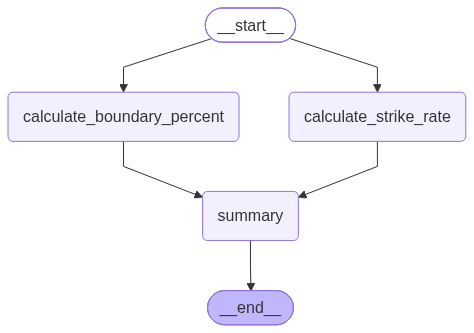

In [18]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_percent")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_boundary_percent", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()
workflow

In [19]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

In [20]:
output_state = workflow.invoke(initial_state)

In [21]:
output_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'boundary_percent': 48.0,
 'summary': '\n    Strike Rate: 200.0\n    Boundary Percentage: 48.0\n    '}

# LLM based Parallel Workflow

In [48]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b",
    max_tokens=512,
    temperature=0
)

In [64]:
class LLMState(TypedDict):
    topic: str
    essay: str

    clarity_of_thought: str
    clarity_of_thought_score: float

    depth_of_analysis: str
    depth_of_analysis_score: float

    language_correctness: str
    language_correctness_score: float

    final_summary: str
    

In [50]:
def generate_essay(state: LLMState) -> dict:

    prompt = f"Generate a short essay on the topic: {state["topic"]}"

    essay = llm.invoke(prompt).content

    return {"essay": essay}

In [51]:
def clarity_of_thought(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of clarity of thought and give a short feedback. Essay: {state["essay"]}"
    
    clarity_of_thought = llm.invoke(prompt).content
    
    return {"clarity_of_thought": clarity_of_thought}

In [52]:
def clarity_of_thought_score(state: LLMState) -> dict:

    prompt = f"""
        Judge the essay on the basis of clarity of thought and give a numerical score between 1-10
    
        Essay: {state["essay"]}
    
        Give a score between 1 and 10.
        Return ONLY the numerical score.
        Do not provide any explanation.
    """
    
    clarity_of_thought_score = llm.invoke(prompt).content
    
    return {"clarity_of_thought_score": clarity_of_thought_score}

In [53]:
def depth_of_analysis(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of depth of analysis and give a short feedback. Essay: {state["essay"]}"
    
    depth_of_analysis = llm.invoke(prompt).content
    
    return {"depth_of_analysis": depth_of_analysis}

In [54]:
def depth_of_analysis_score(state: LLMState) -> dict:

    prompt = f"""
        Judge the essay on the basis of depth of analysis and give a numerical score between 1-10
    
        Essay: {state["essay"]}
    
        Give a score between 1 and 10.
        Return ONLY the numerical score.
        Do not provide any explanation.
    """
    
    depth_of_analysis_score = llm.invoke(prompt).content
    
    return {"depth_of_analysis_score": depth_of_analysis_score}

In [55]:
def language_correctness(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of language correctness and give a short feedback. Essay: {state["essay"]}"
    
    language_correctness = llm.invoke(prompt).content
    
    return {"language_correctness": language_correctness}

In [56]:
def language_correctness_score(state: LLMState) -> dict:

    prompt = f"""
        Judge the essay on the basis of language correctness and give a numerical score between 1-10
    
        Essay: {state["essay"]}
    
        Give a score between 1 and 10.
        Return ONLY the numerical score.
        Do not provide any explanation.
    """
    
    language_correctness_score = llm.invoke(prompt).content
    
    return {"language_correctness_score": language_correctness_score}

In [69]:
def final_summary(state: LLMState) -> LLMState:
    clarity_of_thought = state["clarity_of_thought"]
    depth_of_analysis = state["depth_of_analysis"]
    language_correctness = state["language_correctness"]

    prompt = f"""
    Provide a short summary of an essay based on the following aspects

    Clarity of Score: {clarity_of_thought}
    Depth of Analysis: {depth_of_analysis}
    Language Correctness: {language_correctness}
    """

    final_summary = llm.invoke(prompt).content

    return {"final_summary": final_summary}


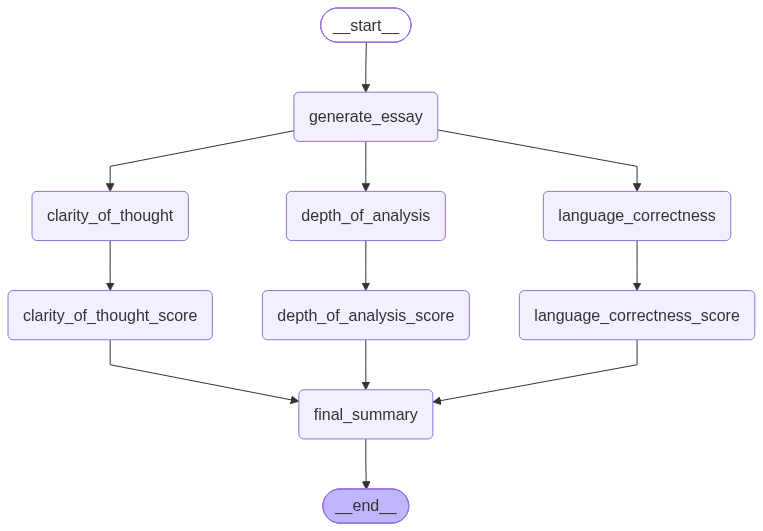

In [70]:
graph = StateGraph(LLMState)

graph.add_node("generate_essay", generate_essay)
graph.add_node("clarity_of_thought", clarity_of_thought)
graph.add_node("clarity_of_thought_score", clarity_of_thought_score)
graph.add_node("depth_of_analysis", depth_of_analysis)
graph.add_node("depth_of_analysis_score", depth_of_analysis_score)
graph.add_node("language_correctness", language_correctness)
graph.add_node("language_correctness_score", language_correctness_score)
graph.add_node("final_summary", final_summary)

graph.add_edge(START, "generate_essay")

graph.add_edge("generate_essay", "clarity_of_thought")
graph.add_edge("generate_essay", "depth_of_analysis")
graph.add_edge("generate_essay", "language_correctness")

graph.add_edge("clarity_of_thought", "clarity_of_thought_score")
graph.add_edge("depth_of_analysis", "depth_of_analysis_score")
graph.add_edge("language_correctness", "language_correctness_score")

graph.add_edge("clarity_of_thought_score", "final_summary")
graph.add_edge("depth_of_analysis_score", "final_summary")
graph.add_edge("language_correctness_score", "final_summary")

graph.add_edge("final_summary", END)

workflow = graph.compile()
workflow

In [71]:
initial_state = {
    "topic": "Issues in Indian Education System"
}

output_state = workflow.invoke(initial_state)

output_state

{'topic': 'Issues in Indian Education System',
 'essay': '**Issues in the Indian Education System**\n\nIndia’s education system, one of the largest in the world, has made remarkable strides in enrolment and literacy over the past few decades. Yet, beneath the impressive statistics lie deep‑rooted challenges that hinder the sector’s ability to deliver equitable, quality learning for all. The most pressing issues can be grouped into four inter‑related domains: access and equity, quality of instruction, relevance of the curriculum, and systemic governance.\n\n---\n\n### 1. Access and Equity  \n\n**Geographic disparity** remains stark. While urban schools often boast modern facilities and internet connectivity, many rural and tribal areas still lack basic infrastructure—adequate classrooms, clean drinking water, and reliable electricity. According to the 2023 ASER report, over 30\u202f% of villages have no functional school building, and a similar share of children travel more than two kil

In [72]:
for key,value in output_state.items():
    print("\n")
    print(f"{key.capitalize()}:")
    print(f"{value}")



Topic:
Issues in Indian Education System


Essay:
**Issues in the Indian Education System**

India’s education system, one of the largest in the world, has made remarkable strides in enrolment and literacy over the past few decades. Yet, beneath the impressive statistics lie deep‑rooted challenges that hinder the sector’s ability to deliver equitable, quality learning for all. The most pressing issues can be grouped into four inter‑related domains: access and equity, quality of instruction, relevance of the curriculum, and systemic governance.

---

### 1. Access and Equity  

**Geographic disparity** remains stark. While urban schools often boast modern facilities and internet connectivity, many rural and tribal areas still lack basic infrastructure—adequate classrooms, clean drinking water, and reliable electricity. According to the 2023 ASER report, over 30 % of villages have no functional school building, and a similar share of children travel more than two kilometres daily, disc